In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/breast.zip'
import zipfile
zip_ref = zipfile.ZipFile(path)
zip_ref.extractall("dataset")
zip_ref.close()

In [ ]:
import pandas as pd
df = pd.read_csv('/content/dataset/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

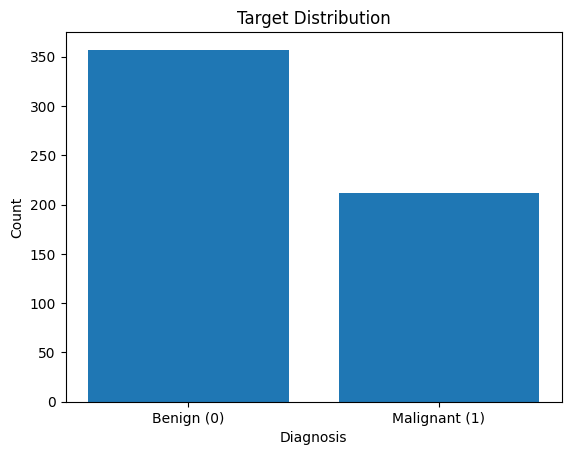

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y, return_counts=True)

plt.bar(unique, counts)
plt.xticks([0, 1], ['Benign (0)', 'Malignant (1)'])
plt.title("Target Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

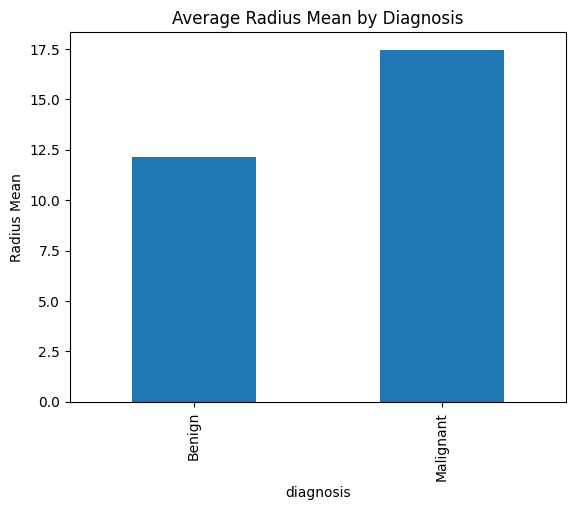

In [ ]:
import pandas as pd

df_plot = pd.DataFrame(X, columns=df.drop('diagnosis', axis=1).columns)

df_plot['diagnosis'] = y

df_plot.groupby('diagnosis')['radius_mean'].mean().plot(kind='bar')
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.title("Average Radius Mean by Diagnosis")
plt.ylabel("Radius Mean")
plt.show()

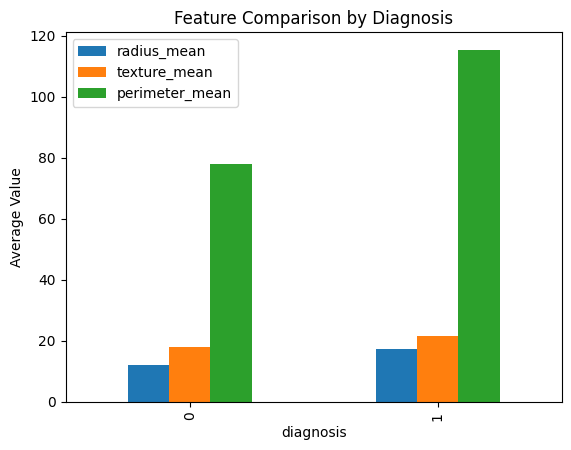

In [ ]:
features = ['radius_mean', 'texture_mean', 'perimeter_mean']

df_plot.groupby('diagnosis')[features].mean().plot(kind='bar')
plt.title("Feature Comparison by Diagnosis")
plt.ylabel("Average Value")
plt.show()

In [ ]:
!pip install pytorch-tabnet

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

In [ ]:
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [ ]:
clf = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [ ]:
clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_name=["test"],
    eval_metric=["accuracy"],
    max_epochs=100,
    patience=10,
    batch_size=64,
    virtual_batch_size=32
)

epoch 0  | loss: 1.00427 | test_accuracy: 0.72807 |  0:00:00s
epoch 1  | loss: 0.52918 | test_accuracy: 0.92982 |  0:00:00s
epoch 2  | loss: 0.45623 | test_accuracy: 0.91228 |  0:00:01s
epoch 3  | loss: 0.3204  | test_accuracy: 0.84211 |  0:00:01s
epoch 4  | loss: 0.32153 | test_accuracy: 0.92105 |  0:00:01s
epoch 5  | loss: 0.22291 | test_accuracy: 0.92105 |  0:00:02s
epoch 6  | loss: 0.26218 | test_accuracy: 0.94737 |  0:00:02s
epoch 7  | loss: 0.21609 | test_accuracy: 0.95614 |  0:00:03s
epoch 8  | loss: 0.23969 | test_accuracy: 0.92982 |  0:00:03s
epoch 9  | loss: 0.23669 | test_accuracy: 0.9386  |  0:00:04s
epoch 10 | loss: 0.19553 | test_accuracy: 0.98246 |  0:00:04s
epoch 11 | loss: 0.19372 | test_accuracy: 0.97368 |  0:00:05s
epoch 12 | loss: 0.1545  | test_accuracy: 0.97368 |  0:00:06s
epoch 13 | loss: 0.23507 | test_accuracy: 0.97368 |  0:00:06s
epoch 14 | loss: 0.18583 | test_accuracy: 0.97368 |  0:00:07s
epoch 15 | loss: 0.15404 | test_accuracy: 0.97368 |  0:00:07s
epoch 16

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9824561403508771


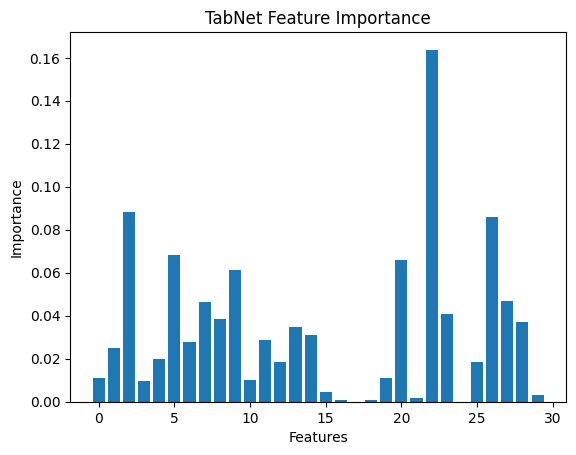

In [ ]:
import matplotlib.pyplot as plt

feature_importances = clf.feature_importances_

plt.bar(range(len(feature_importances)), feature_importances)
plt.title("TabNet Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



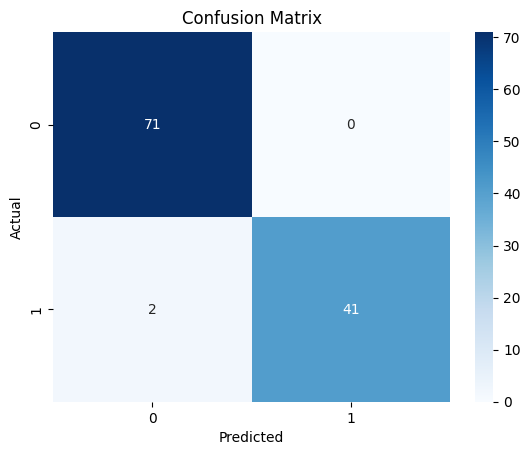

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_prob = clf.predict_proba(X_test)[:, 1]

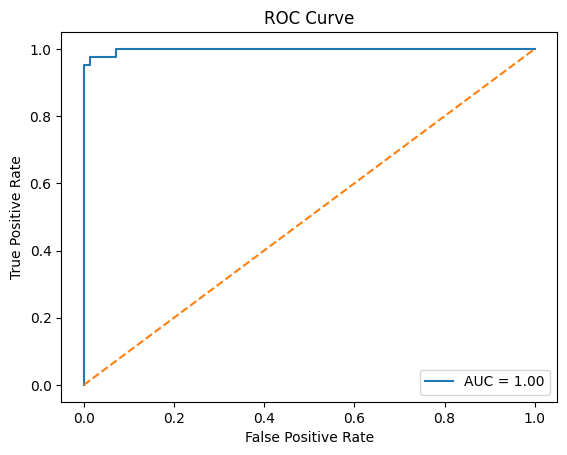

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
print("AUC Score:", roc_auc)

AUC Score: 0.9980347199475925


In [ ]:
y_prob_tabnet = clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
auc_tabnet = roc_auc_score(y_test, y_prob_tabnet)

print("TabNet AUC:", auc_tabnet)
print("XGBoost AUC:", roc_auc)

TabNet AUC: 0.9980347199475925
XGBoost AUC: 0.9980347199475925


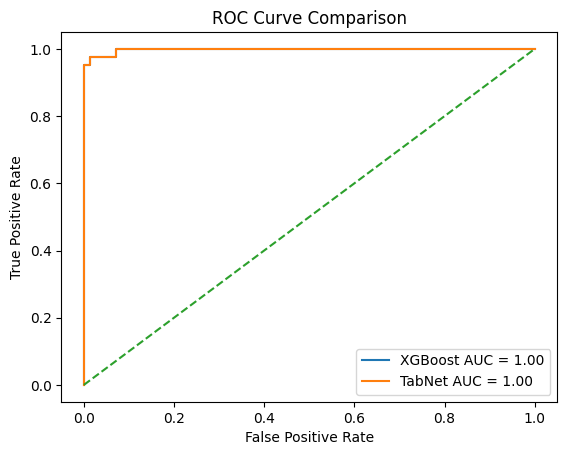

In [ ]:
fpr_tab, tpr_tab, _ = roc_curve(y_test, y_prob_tabnet)

plt.plot(fpr, tpr, label=f"XGBoost AUC = {roc_auc:.2f}")
plt.plot(fpr_tab, tpr_tab, label=f"TabNet AUC = {auc_tabnet:.2f}")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
!pip install xgboost shap

In [ ]:
import shap

X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:47:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

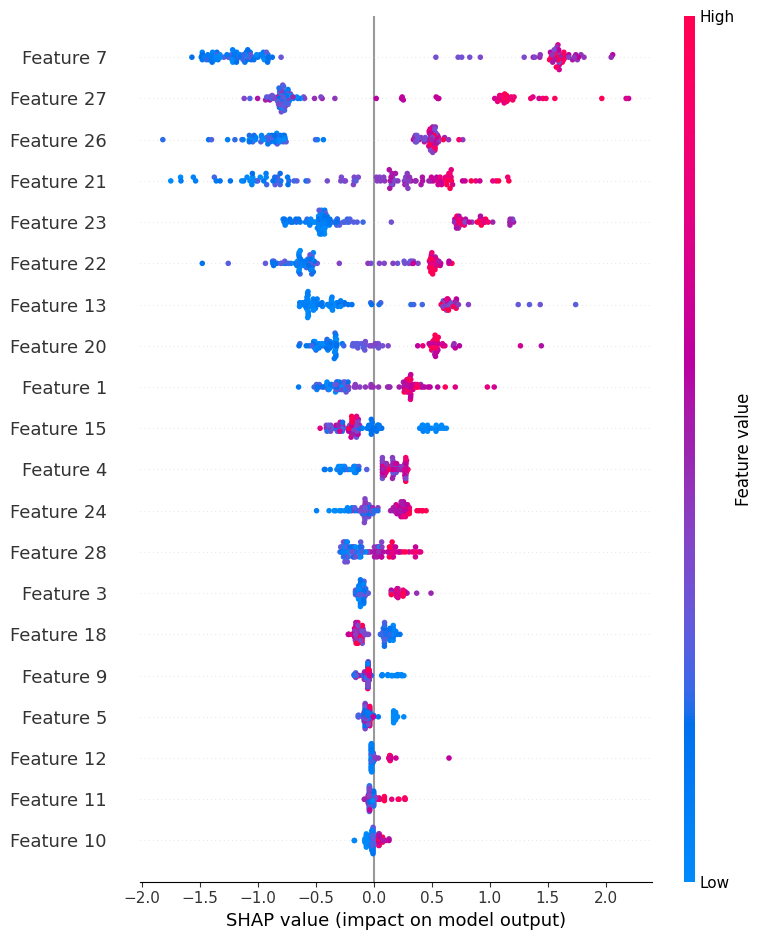

In [ ]:
shap.summary_plot(shap_values, X_test)

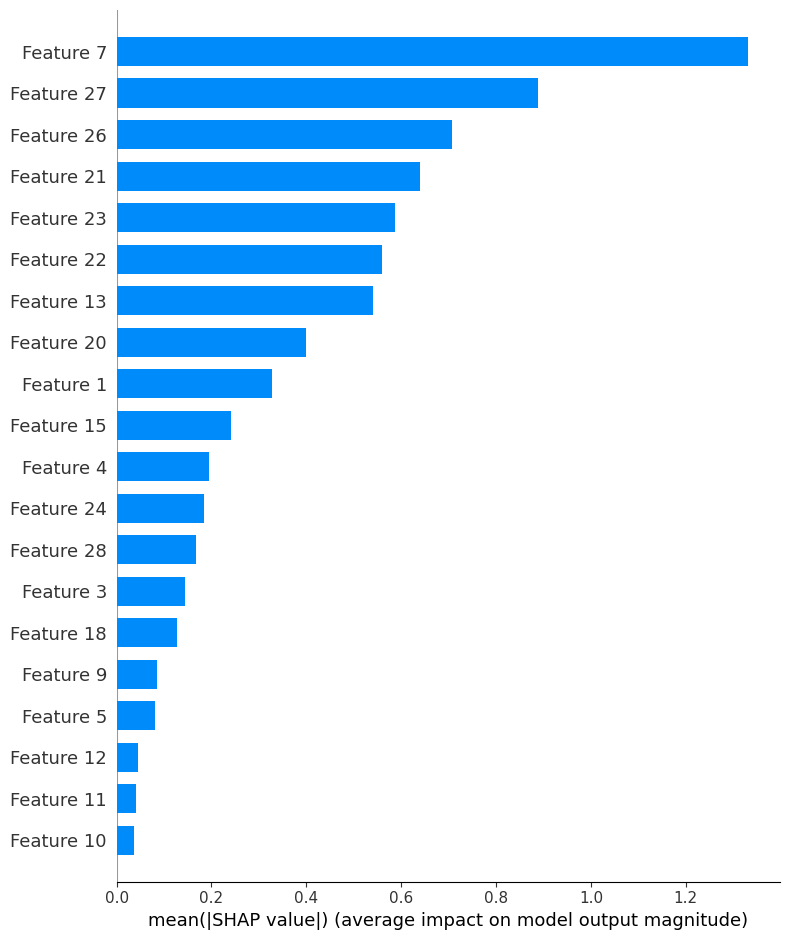

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
class BreastCancerAgent:
    def __init__(self, model, explainer):
        self.model = model
        self.explainer = explainer

    def predict(self, x):
        prob = self.model.predict_proba(x)[0][1]
        pred = int(prob >= 0.5)
        return pred, prob

    def explain(self, x):
        shap_val = self.explainer(x)
        return shap_val

    def decision(self, pred, prob):
        if pred == 1 and prob > 0.8:
            return "HIGH RISK → Immediate oncology consultation"
        elif pred == 1:
            return "MODERATE RISK → Further diagnostic tests"
        else:
            return "LOW RISK → Routine monitoring"

    def report(self, x):
        pred, prob = self.predict(x)
        explanation = self.explain(x)
        decision = self.decision(pred, prob)

        return {
            "prediction": pred,
            "probability": prob,
            "decision": decision,
            "explanation": explanation
        }

In [ ]:
agent = BreastCancerAgent(xgb_model, explainer)

In [ ]:
sample = X_test[0].reshape(1, -1)

result = agent.report(sample)

print("Prediction:", result["prediction"])
print("Probability:", result["probability"])
print("Decision:", result["decision"])

Prediction: 0
Probability: 0.0070903297
Decision: LOW RISK → Routine monitoring


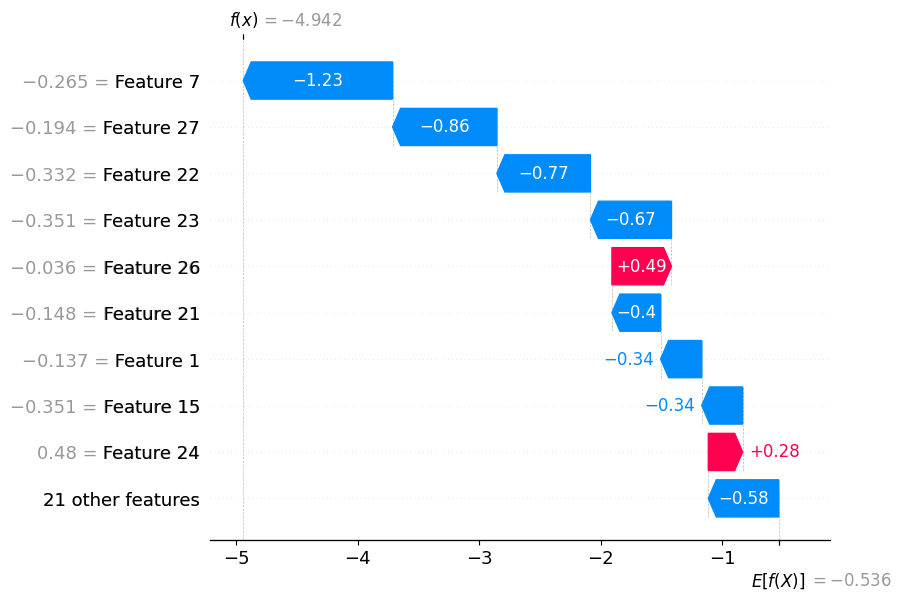

In [ ]:
import shap

shap.plots.waterfall(result["explanation"][0])

In [ ]:
#for i in range(5):
#    sample = X_test[i].reshape(1, -1)
#    result = agent.report(sample)

#    print(f"\nPatient {i+1}")
#    print("Prediction:", result["prediction"])
#    print("Probability:", result["probability"])
#    print("Decision:", result["decision"])


Patient 1
Prediction: 0
Probability: 0.0070903297
Decision: LOW RISK → Routine monitoring

Patient 2
Prediction: 1
Probability: 0.99818414
Decision: HIGH RISK → Immediate oncology consultation

Patient 3
Prediction: 1
Probability: 0.9976478
Decision: HIGH RISK → Immediate oncology consultation

Patient 4
Prediction: 0
Probability: 0.0013760601
Decision: LOW RISK → Routine monitoring

Patient 5
Prediction: 0
Probability: 0.0007364022
Decision: LOW RISK → Routine monitoring


In [ ]:
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save XGBoost model
joblib.dump(xgb_model, "xgb_model.pkl")

# Save feature names (VERY IMPORTANT)
feature_names = df.drop('diagnosis', axis=1).columns.tolist()
joblib.dump(feature_names, "features.pkl")

['features.pkl']

In [ ]:
from google.colab import drive
import os
import joblib

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Create a folder to store models
save_path = "/content/drive/MyDrive/models"
os.makedirs(save_path, exist_ok=True)

# 3. Prepare feature names (VERY IMPORTANT)
feature_names = df.drop('diagnosis', axis=1).columns.tolist()

# 4. Save all components separately
joblib.dump(xgb_model, f"{save_path}/xgb_model.pkl")
joblib.dump(scaler, f"{save_path}/scaler.pkl")
joblib.dump(feature_names, f"{save_path}/features.pkl")

print(" Saved successfully!")
print(" Location: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Saved successfully!
 Location: {save_path}
